<a href="https://colab.research.google.com/github/victorialms/ExVisuDados/blob/main/Exerc%C3%ADcio__Pr%C3%A1tico_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [3]:
import pandas as pd


df = pd.read_csv('vendas_brasil_clean_aula5.csv')

# 1
print('Primeiras 5 linhas do DataFrame:')
display(df.head())

# 2
print(f'\nTamanho da base: {df.shape[0]} linhas e {df.shape[1]} colunas')

# 3
print('\nTipos das colunas:')
display(df.info())

#4
print('\nVariáveis:')
print('- Comparação: canal_venda, segmento, categoria, uf')
print('- Tendência: mes (após conversão para tipo temporal)')
print('- Distribuição: margem_lucro, receita, lucro')
print('- Relação entre métricas: receita vs lucro')

Primeiras 5 linhas do DataFrame:


,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03



Tamanho da base: 480 linhas e 12 colunas

Tipos das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   data            480 non-null    object 
 1   uf              480 non-null    object 
 2   canal_venda     480 non-null    object 
 3   segmento        480 non-null    object 
 4   categoria       480 non-null    object 
 5   produto         480 non-null    object 
 6   quantidade      480 non-null    int64  
 7   preco_unitario  480 non-null    float64
 8   receita         480 non-null    float64
 9   lucro           480 non-null    float64
 10  margem_lucro    480 non-null    float64
 11  mes             480 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 45.1+ KB


None


Variáveis:
- Comparação: canal_venda, segmento, categoria, uf
- Tendência: mes (após conversão para tipo temporal)
- Distribuição: margem_lucro, receita, lucro
- Relação entre métricas: receita vs lucro


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


**Pergunta do gestor**: Qual canal de vendas gera maior receita?

**Variáveis (Pandas)**: canal, receita

**Tipo de gráfico**: barras

**Biblioteca sugerida**: seaborn

**Pergunta do gestor**: Como o lucro se comporta ao longo do tempo?

**Variáveis (Pandas)**: data ou mes, lucro

**Tipo de gráfico**: linha

**Biblioteca sugerida**: matplotlib

**Pergunta do gestor**: Quais estados possuem maior volume de vendas?

**Variáveis (Pandas)**: estado, quantidade_vendida

**Tipo de gráfico**: barras

**Biblioteca sugerida**: seaborn

**Pergunta do gestor**: Como está a distribuição dos preços dos produtos? Existem valores muito fora do padrão?

**Variáveis (Pandas)**: preco

**Tipo de gráfico**: boxplot

**Biblioteca sugerida**: matplotlib ou seaborn

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


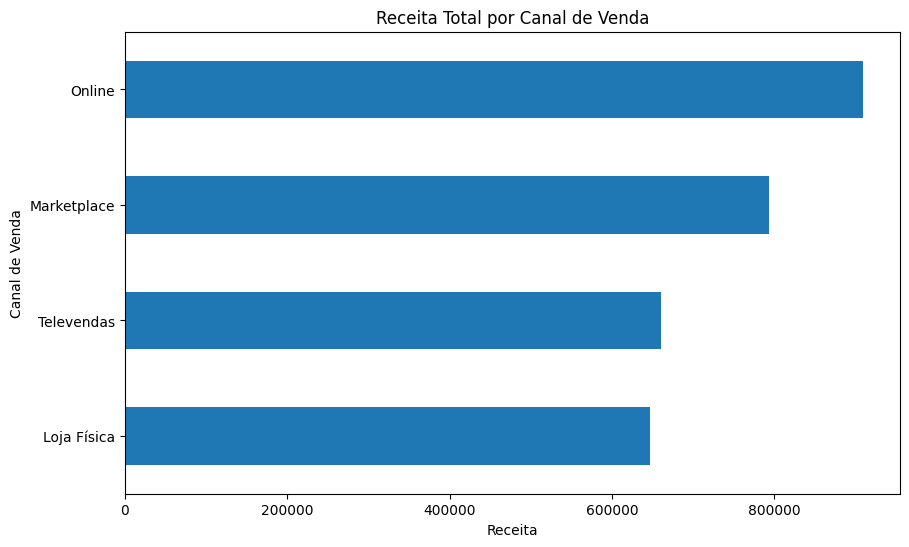

In [7]:
import matplotlib.pyplot as plt

# Construa aqui o gráfico de barras horizontais por canal_venda

# Agrupando
receita_canal = df.groupby('canal_venda')['receita'].sum()

receita_canal = receita_canal.sort_values()

# gráfico de barras horizontais
plt.figure(figsize=(10,6))
receita_canal.plot(kind='barh')

plt.title('Receita Total por Canal de Venda')
plt.xlabel('Receita')
plt.ylabel('Canal de Venda')

# exibir
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


O canal Online lidera em receita, mostrando maior eficiência e alcance.

O canal Loja Física aparece atrás, com menor desempenho.

Como ação tática, o gestor pode investigar os motivos da baixa performance da loja física e decidir se vale a pena reforçar investimentos nesse canal ou redirecionar recursos para expandir ainda mais o canal online, que já demonstra maior retorno.

## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


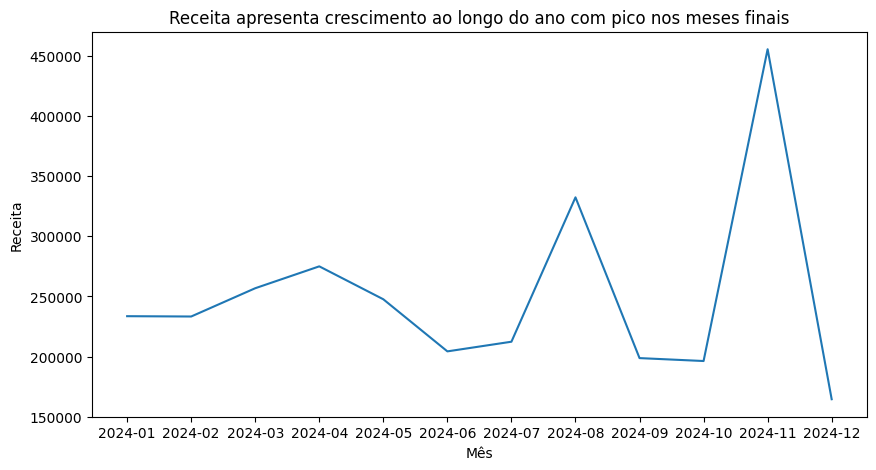

In [8]:
# Construa aqui o gráfico de linha temporal da receita por mês

# ordenação temporal
receita_mes = df.groupby('mes')['receita'].sum().sort_index()

# gráfico de linha
plt.figure(figsize=(10,5))
plt.plot(receita_mes.index, receita_mes.values)

# titulo pro grafico
plt.title('Receita apresenta crescimento ao longo do ano com pico nos meses finais')

plt.xlabel('Mês')
plt.ylabel('Receita')

# Exibir
plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


Há sinais claros de sazonalidade, pois a receita varia ao longo do tempo e apresenta picos evidentes no fim do ano, quando as vendas aumentam de forma significativa.

O título do gráfico é útil para o gestor, já que destaca diretamente o insight principal e facilita a interpretação rápida dos dados sem necessidade de uma análise detalhada.

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


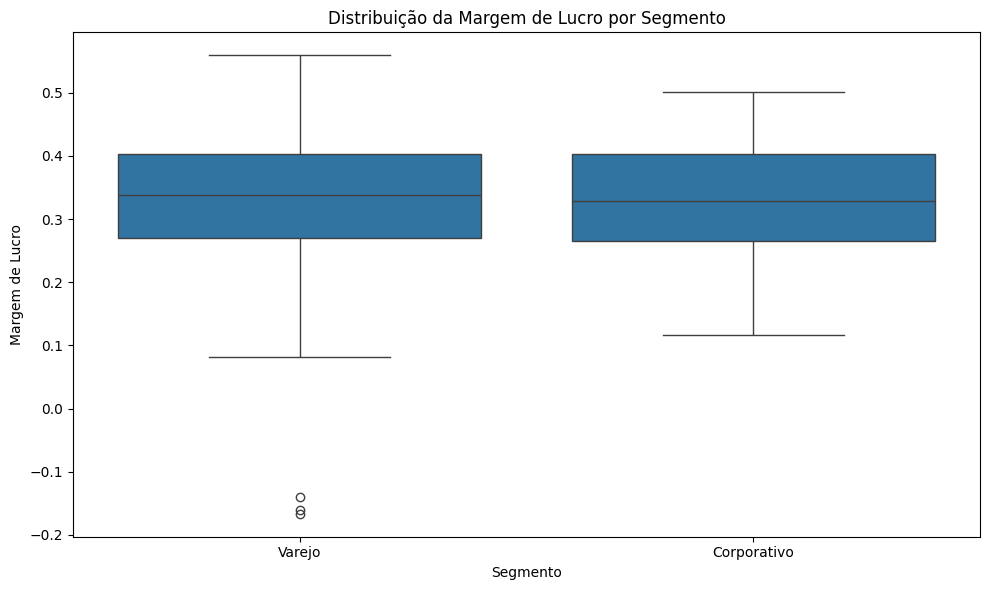

In [10]:
import seaborn as sns

# Construa aqui o boxplot de margem_lucro por segmento
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x='segmento', y='margem_lucro')

plt.title('Distribuição da Margem de Lucro por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Margem de Lucro')

plt.tight_layout()
plt.show()

O segmento Varejo mostra maior estabilidade, já que sua caixa é mais compacta e os “bigodes” são curtos, indicando menor variação na margem de lucro.

O segmento Corporativo apresenta maior dispersão e risco, com caixa mais longa e presença de outliers, revelando margens menos previsíveis e oscilações significativas.

Para o gestor, o Varejo representa previsibilidade e segurança, ideal para estratégias de volume. Já o Corporativo exige atenção aos riscos: é importante investigar as causas das margens muito baixas e buscar formas de replicar as condições que geram margens altas, equilibrando oportunidades e perdas.

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


O segmento de Varejo é o mais consistente.O tamanho da caixa é menor, o que indica que a maioria das vendas ocorre dentro de uma margem de lucro previsível e estável.

O segmento Corporativo apresenta maior risco. Além de uma dispersão maior nas margens, observamos a presença de outliers. Isso significa que, embora existam vendas muito lucrativas, também ocorrem casos com margens significativamente baixas, tornando o retorno menos garantido.

A decisão comercial pode ser afetada de acordo com estas estratégias:

* Estratégia de Varejo: Focar em ganho de escala e eficiência operacional, já que o retorno é estável.

* Estratégia Corporativa: Implementar critérios mais rigorosos de concessão de descontos ou análise de custos por contrato, visando reduzir a ocorrência de margens baixas e tentar padronizar o sucesso das vendas de alta margem.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


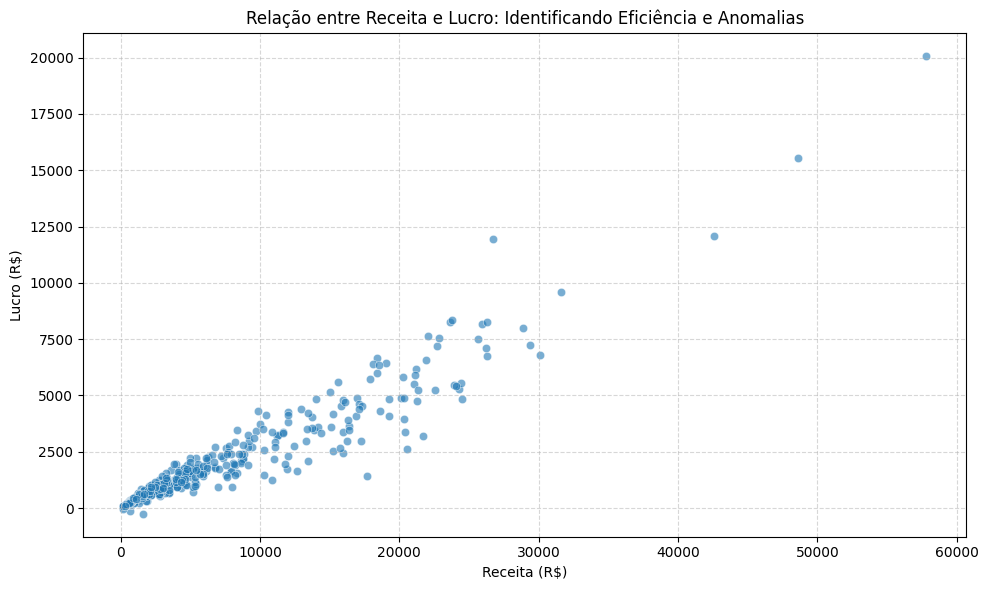

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.6)

plt.title('Relação entre Receita e Lucro: Identificando Eficiência e Anomalias')
plt.xlabel('Receita (R$)')
plt.ylabel('Lucro (R$)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

A relação entre receita e lucro mostra uma tendência positiva: quanto maior a receita, maior tende a ser o lucro.

Porém, há pontos fora desse padrão — casos de alta receita com baixo lucro. Isso sugere problemas como custos elevados, descontos agressivos ou falhas operacionais. Para o gestor, esses desvios são sinais de alerta: é essencial investigar os fatores que comprimem a margem e ajustar processos para garantir que o crescimento da receita se traduza em lucratividade real.

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


Há uma correlação positiva: conforme a receita cresce, o lucro tende a acompanhar.

Ainda assim, existem anomalias — pontos de alta receita com lucro baixo ou até negativo. Isso sinaliza possíveis falhas ligadas a custos, descontos ou canais específicos. Para o gestor, o caminho é investigar esses casos fora do padrão e identificar onde a rentabilidade está sendo comprometida, ajustando processos e estratégias para garantir que o aumento de receita se traduza em lucro consistente.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


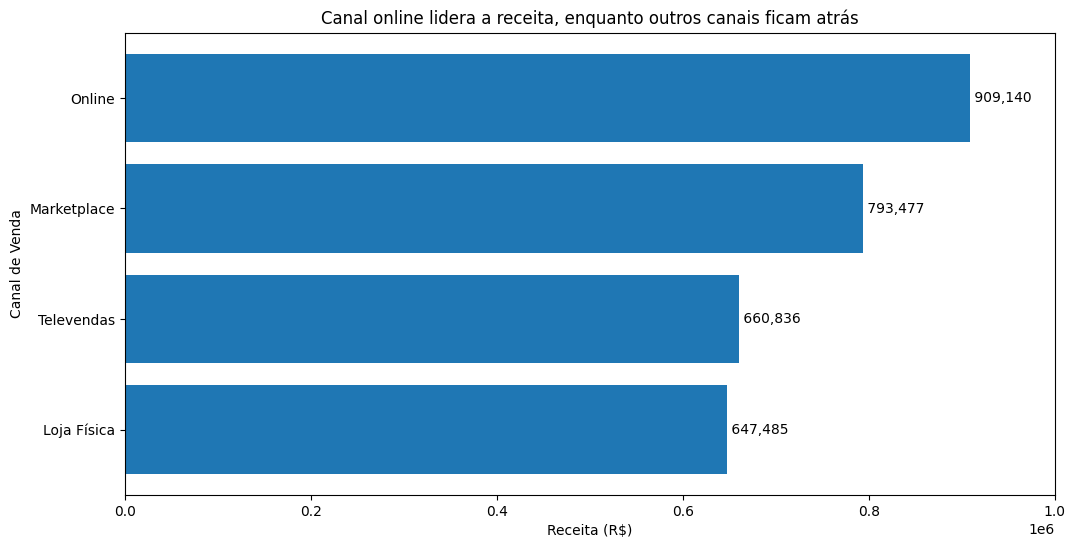

In [12]:
# Refaça aqui um dos gráficos com foco em simplicidade e clareza

receita_canal = (
    df.groupby('canal_venda')['receita']
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,6))

bars = plt.barh(receita_canal.index, receita_canal.values)

plt.title('Canal online lidera a receita, enquanto outros canais ficam atrás')

#eixos claros
plt.xlabel('Receita (R$)')
plt.ylabel('Canal de Venda')


max_val = receita_canal.max()
plt.xlim(0, max_val * 1.1)

# Valores nas barras
for i, v in enumerate(receita_canal.values):
    plt.text(v, i, f' {v:,.0f}', va='center')

plt.grid(False)

plt.show()

Agora o gráfico ficou mais claro: os rótulos de valores eliminam a necessidade de estimar visualmente cada barra, permitindo leitura direta e precisa. Além disso, o título mais interpretativo orienta o gestor para o insight principal, tornando a visualização não apenas descritiva, mas também informativa e fácil de compreender.

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


Ordenar as barras torna a comparação direta entre categorias muito mais intuitiva, destacando rapidamente quem lidera e quem está atrás.

Já truncar o eixo Y pode distorcer a percepção, ampliando diferenças pequenas e induzindo interpretações equivocadas.

Por isso, manter a base zero em gráficos de barras é fundamental: como o comprimento das barras representa os valores, qualquer corte no eixo compromete a transparência e gera comparações visuais enganosas.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


Gráficos de pizza são úteis apenas quando há poucas categorias, pois muitas fatias tornam a leitura confusa e dificultam a comparação de ângulos semelhantes.

O uso de efeitos em 3D compromete a precisão, já que elementos mais próximos parecem maiores do que realmente são, distorcendo a interpretação.

Além disso, aplicar muitas cores sem critério gera ruído visual e atrapalha a identificação de padrões. Para comunicar bem, é melhor usar paletas simples e consistentes, mantendo o foco nos dados.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


#Receita por Canal (Barras)
Descritivo:
“Receita total por canal de venda”

Analítico:
Canal online concentra a maior parte da receita, enquanto demais canais têm participação reduzida

#Receita ao longo do tempo (Linha)
Descritivo:
“Receita por mês”

Analítico:
“Receita cresce ao longo do ano com aceleração nos meses finais”


## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


O canal Online se destaca como principal fonte de receita, concentrando a maior parte do caixa em relação aos demais.

Há um padrão claro de crescimento ao longo do ano, com aceleração nos meses finais, evidenciando forte sazonalidade nesse período.

Quanto aos segmentos, o Corporativo mostra maior estabilidade nas margens de lucro, enquanto o Varejo apresenta maior volatilidade, trazendo mais risco e exigindo atenção na gestão.

## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


### 📊 Avaliação do gráfico

* O gráfico responde claramente à pergunta original?  
Sim. Ele está alinhado com o objetivo e evidencia o insight principal de forma direta.

* Você removeu linhas, bordas e legendas que não agregam?  
Sim. A visualização foi simplificada, mantendo apenas os elementos essenciais.

* Os eixos estão honestos e não distorcem a realidade?  
Sim. A escala foi preservada corretamente, sem manipulações que comprometam a interpretação.

* As cores foram usadas com intenção?  
Sim. Foram aplicadas de maneira consistente e funcional, destacando a informação relevante.

* Há um pequeno texto explicando o insight?  
Sim. O título e a anotação complementam o gráfico, comunicando o insight de forma clara e objetiva.


## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


In [ ]:
# Desafio extra opcional


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
